<a href="https://colab.research.google.com/github/Nab123-bot/-medical-multi-agent/blob/main/Projet_Exlporation_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk

In [ ]:
import pandas as pd

# Lien direct vers le fichier CSV sur GitHub
url = "https://raw.githubusercontent.com/fratsaislam/Spaceship-Titanic-Kaggle/main/train.csv"

# Chargement du jeu de données
df = pd.read_csv(url)

print(df.shape)  # Devrait afficher (8693, 14)
print(df.head())

(8693, 14)
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4       

=== df.describe() – variables numériques ===
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  

=== Valeurs manquantes par colonne ===
              

/tmp/ipykernel_2047/3511059145.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(cols_with_missing.index, rotation=45, ha='right')


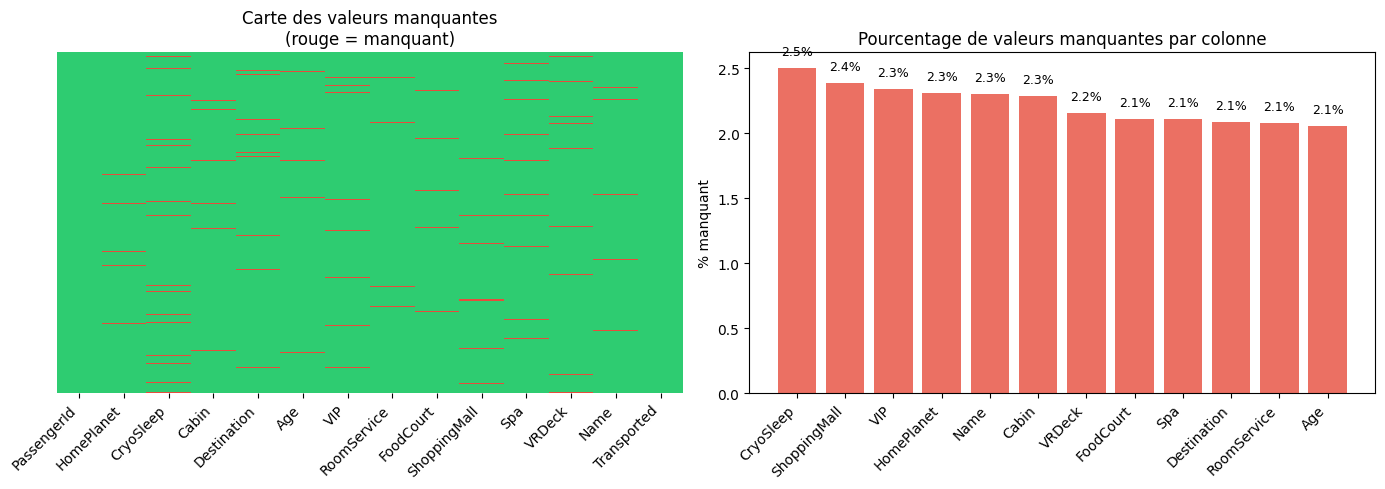

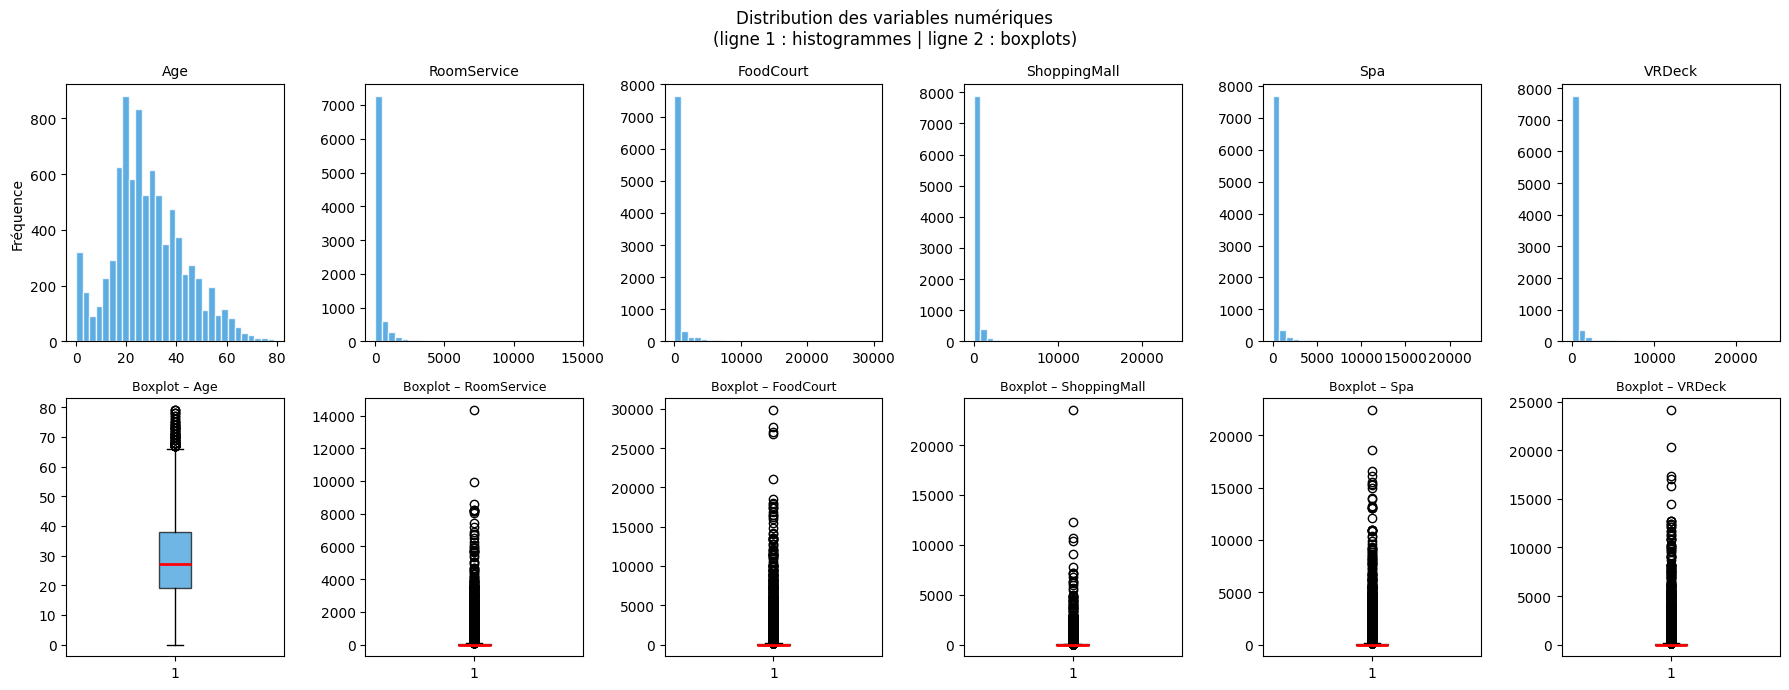

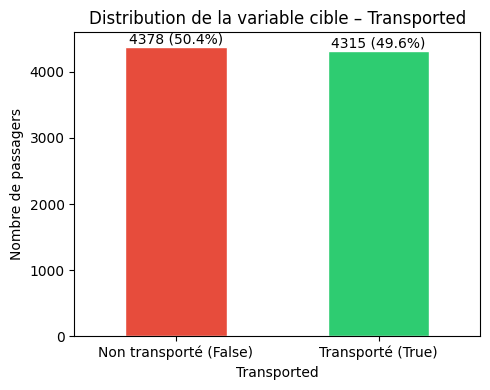


=== Valeurs aberrantes détectées (IQR) ===
  Age: 77 valeurs aberrantes détectées (max=79.0)
  RoomService: 1861 valeurs aberrantes détectées (max=14327.0)
  FoodCourt: 1823 valeurs aberrantes détectées (max=29813.0)
  ShoppingMall: 1829 valeurs aberrantes détectées (max=23492.0)
  Spa: 1788 valeurs aberrantes détectées (max=22408.0)
  VRDeck: 1809 valeurs aberrantes détectées (max=24133.0)


In [ ]:
# ============================================================
# EXPLORATION INITIALE – Statistiques descriptives & visualisations
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/fratsaislam/Spaceship-Titanic-Kaggle/main/train.csv"
df = pd.read_csv(url)

# --- 1. Statistiques descriptives ---
print("=== df.describe() – variables numériques ===")
print(df.describe())

print("\n=== Valeurs manquantes par colonne ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, '%': missing_pct})
print(missing_df[missing_df['Manquants'] > 0])

print("\n=== Cardinalité des variables catégorielles ===")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} valeurs uniques  |  exemple: {df[col].dropna().unique()[:4]}")

# --- 2. Heatmap des valeurs manquantes ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap style missingno simplifié
missing_matrix = df.isnull()
sns.heatmap(missing_matrix, cbar=False, yticklabels=False,
            cmap=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title("Carte des valeurs manquantes\n(rouge = manquant)", fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Barplot des % manquants
cols_with_missing = missing_pct[missing_pct > 0].sort_values(ascending=False)
axes[1].bar(cols_with_missing.index, cols_with_missing.values, color='#e74c3c', alpha=0.8)
axes[1].set_title("Pourcentage de valeurs manquantes par colonne", fontsize=12)
axes[1].set_ylabel("% manquant")
axes[1].set_xticklabels(cols_with_missing.index, rotation=45, ha='right')
for i, v in enumerate(cols_with_missing.values):
    axes[1].text(i, v + 0.1, f"{v:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# --- 3. Distribution des variables numériques (histogrammes + boxplots) ---
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, len(numeric_cols), figsize=(18, 7))
for i, col in enumerate(numeric_cols):
    # Histogramme
    axes[0, i].hist(df[col].dropna(), bins=30, color='#3498db', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(col, fontsize=10)
    axes[0, i].set_ylabel("Fréquence" if i == 0 else "")
    # Boxplot
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f"Boxplot – {col}", fontsize=9)

plt.suptitle("Distribution des variables numériques\n(ligne 1 : histogrammes | ligne 2 : boxplots)", fontsize=12)
plt.tight_layout()
plt.show()

# --- 4. Distribution de la cible ---
fig, ax = plt.subplots(figsize=(5, 4))
df['Transported'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax, edgecolor='white')
ax.set_title("Distribution de la variable cible – Transported", fontsize=12)
ax.set_xticklabels(['Non transporté (False)', 'Transporté (True)'], rotation=0)
ax.set_ylabel("Nombre de passagers")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# --- 5. Valeurs aberrantes : commentaire ---
print("\n=== Valeurs aberrantes détectées (IQR) ===")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)][col]
    print(f"  {col}: {len(outliers)} valeurs aberrantes détectées (max={df[col].max():.1f})")


Dimensions : (8693, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age          

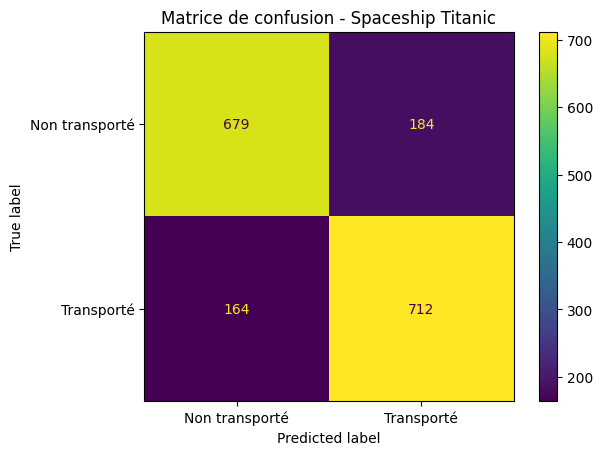

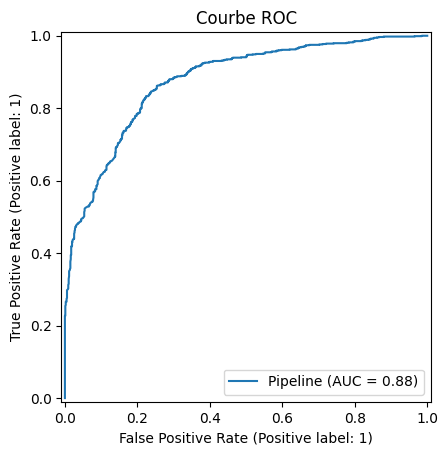

                precision    recall  f1-score   support

Non transporté       0.81      0.79      0.80       863
    Transporté       0.79      0.81      0.80       876

      accuracy                           0.80      1739
     macro avg       0.80      0.80      0.80      1739
  weighted avg       0.80      0.80      0.80      1739



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, KBinsDiscretizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay

# 1. Chargement
url = "https://raw.githubusercontent.com/fratsaislam/Spaceship-Titanic-Kaggle/main/train.csv"
df = pd.read_csv(url)

print("Dimensions :", df.shape)
print(df.info())
print(df.isnull().sum())

# 2. Nettoyage initial
# On supprime les colonnes inutiles : PassengerId (identifiant), Name (pas de nom ici ? vérifions)
# En réalité, Spaceship Titanic a : PassengerId, HomePlanet, CryoSleep, Cabin, Destination, Age, VIP, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Name (existe ? non)
# D'après le dataset, les colonnes sont : PassengerId, HomePlanet, CryoSleep, Cabin, Destination, Age, VIP, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Transported
# Il n'y a pas de colonne 'name' ni 'title' à extraire.

# Création de la variable family_size ? On peut utiliser les dépenses totales ou le nombre de services utilisés.
# Pour simplifier, on va utiliser les colonnes numériques existantes.

# Sélection des colonnes pertinentes
target = 'Transported'
features = [col for col in df.columns if col != target]
# On exclut PassengerId et Cabin (trop de NA ou identifiant)
features_to_keep = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP',
                    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
X = df[features_to_keep]
y = df[target].astype(int)  # conversion bool -> int

# 3. Définition des types de colonnes
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
categorical_nominal = ['HomePlanet', 'Destination', 'VIP']  # VIP est binaire mais on le traite comme nominal
binary_cols = ['CryoSleep']  # True/False, on peut l'encoder en OneHot ou Ordinal

# 4. Prétraitement
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('nom', nominal_transformer, categorical_nominal),
    ('bin', binary_transformer, binary_cols)
])

# 5. Pipelines
pipeline_lr = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# 6. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Évaluation préliminaire
for name, pipe in [('LogReg', pipeline_lr), ('RF', pipeline_rf)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}: CV accuracy = {scores.mean():.4f} ± {scores.std():.4f}")
    pipe.fit(X_train, y_train)
    print(f"Test accuracy = {pipe.score(X_test, y_test):.4f}\n")

# 8. GridSearch sur Random Forest
param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10]
}
grid = GridSearchCV(pipeline_rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params :", grid.best_params_)
print("Best CV score :", grid.best_score_)
print("Test score :", grid.score(X_test, y_test))

# 9. Visualisations
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=['Non transporté', 'Transporté'])
plt.title("Matrice de confusion - Spaceship Titanic")
plt.show()

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Courbe ROC")
plt.show()

print(classification_report(y_test, y_pred, target_names=['Non transporté', 'Transporté']))

In [ ]:
# ============================================================
# PARTIE I – Pipeline alternatif : Discrétisation de l'âge
# ============================================================
from sklearn.preprocessing import KBinsDiscretizer

# Transformer pour Age : imputation → discrétisation → scaling
num_transformer_disc = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('discretizer', KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')),
    ('scaler', StandardScaler())
])

# Transformer pour les autres numériques : imputation → scaling
# (CORRECTION : SimpleImputer ajouté pour gérer les ~2 % de valeurs manquantes)
other_num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_disc = ColumnTransformer([
    ('num_age',       num_transformer_disc,  ['Age']),
    ('other_num',     other_num_transformer, ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']),
    ('nom',           nominal_transformer,   categorical_nominal),
    ('bin',           binary_transformer,    binary_cols)
])

pipeline_rf_disc = Pipeline([
    ('prep', preprocessor_disc),
    ('clf',  RandomForestClassifier(random_state=42))
])

param_grid_disc = {
    'clf__n_estimators':     [50, 100, 200],
    'clf__max_depth':        [None, 10, 20],
    'clf__min_samples_split':[2, 5, 10]
}

grid_disc = GridSearchCV(pipeline_rf_disc, param_grid_disc, cv=5, scoring='accuracy', n_jobs=-1)
grid_disc.fit(X_train, y_train)

print("Meilleurs paramètres (avec discrétisation) :", grid_disc.best_params_)
print("Score CV   :", round(grid_disc.best_score_, 4))
print("Score test :", round(grid_disc.score(X_test, y_test), 4))

Meilleurs paramètres (avec discrétisation) : {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Score test : 0.7964347326049454


In [ ]:
# ============================================================
# PARTIE II – Chargement du corpus 20 Newsgroups
# ============================================================
from sklearn.datasets import fetch_20newsgroups
import numpy as np

categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
news_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
news_test  = fetch_20newsgroups(subset='test',  categories=categories, shuffle=True, random_state=42)

# Variables renommées _text pour ne pas écraser X_train/X_test de la Partie I
X_train_text = news_train.data
y_train_text = news_train.target
X_test_text  = news_test.data
y_test_text  = news_test.target

print("Classes :",        news_train.target_names)
print("Taille train :",   len(X_train_text), " | test :", len(X_test_text))
print("Longueur moyenne des documents (en mots) :",
      round(np.mean([len(doc.split()) for doc in X_train_text]), 1))

Classes : ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']
Taille train : 2257 test : 1502
Longueur moyenne des documents (en mots) : 308.46787771377933


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

def evaluate_vectorizer(vectorizer, X_train, y_train, X_test, y_test, name):
    vec = vectorizer
    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)
    clf = MultinomialNB(alpha=0.1)
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} : Accuracy = {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=news_train.target_names))
    return vec, clf, X_train_vec.shape

# Expérience 1 – CountVectorizer unigrammes
count_uni = CountVectorizer(max_features=5000, stop_words='english')
evaluate_vectorizer(count_uni, X_train_text, y_train_text, X_test_text, y_test_text, "Count (unigram)")

# Expérience 2 – CountVectorizer bigrammes
count_bi = CountVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
evaluate_vectorizer(count_bi, X_train_text, y_train_text, X_test_text, y_test_text, "Count (1,2)-gram")

# Expérience 3 – TF-IDF unigrammes
tfidf_uni = TfidfVectorizer(max_features=5000, stop_words='english')
evaluate_vectorizer(tfidf_uni, X_train_text, y_train_text, X_test_text, y_test_text, "TF-IDF (unigram)")

# Expérience 4 – TF-IDF avec (1,3)-grammes
tfidf_ngram = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,3))
evaluate_vectorizer(tfidf_ngram, X_train_text, y_train_text, X_test_text, y_test_text, "TF-IDF (1-3 gram)")

# (Optionnel) HashingVectorizer – discuter de l'intérêt (pas de vocabulaire, non inversible)
from sklearn.feature_extraction.text import HashingVectorizer
hash_vec = HashingVectorizer(n_features=2**14, alternate_sign=False)
evaluate_vectorizer(hash_vec, X_train_text, y_train_text, X_test_text, y_test_text, "HashingVectorizer")

Count (unigram) : Accuracy = 0.9341
                        precision    recall  f1-score   support

           alt.atheism       0.92      0.89      0.91       319
         comp.graphics       0.94      0.95      0.95       389
               sci.med       0.93      0.94      0.93       396
soc.religion.christian       0.94      0.94      0.94       398

              accuracy                           0.93      1502
             macro avg       0.93      0.93      0.93      1502
          weighted avg       0.93      0.93      0.93      1502

Count (1,2)-gram : Accuracy = 0.9234
                        precision    recall  f1-score   support

           alt.atheism       0.93      0.88      0.90       319
         comp.graphics       0.91      0.96      0.93       389
               sci.med       0.94      0.90      0.92       396
soc.religion.christian       0.92      0.95      0.94       398

              accuracy                           0.92      1502
             macro avg    

(HashingVectorizer(alternate_sign=False, n_features=16384),
 MultinomialNB(alpha=0.1),
 (2257, 16384))

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Pipeline avec TF-IDF et Logistic Regression
pipe_lr = Pipeline([
    ('vec', TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, C=1.0))
])

# Pipeline avec TF-IDF et LinearSVC
pipe_svm = Pipeline([
    ('vec', TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))),
    ('clf', LinearSVC(C=1.0, max_iter=2000))
])

# Évaluation
for name, pipe in [('LR', pipe_lr), ('SVM', pipe_svm)]:
    pipe.fit(X_train_text, y_train_text)
    acc = pipe.score(X_test_text, y_test_text)
    print(f"{name} accuracy : {acc:.4f}")

LR accuracy : 0.9028
SVM accuracy : 0.9194


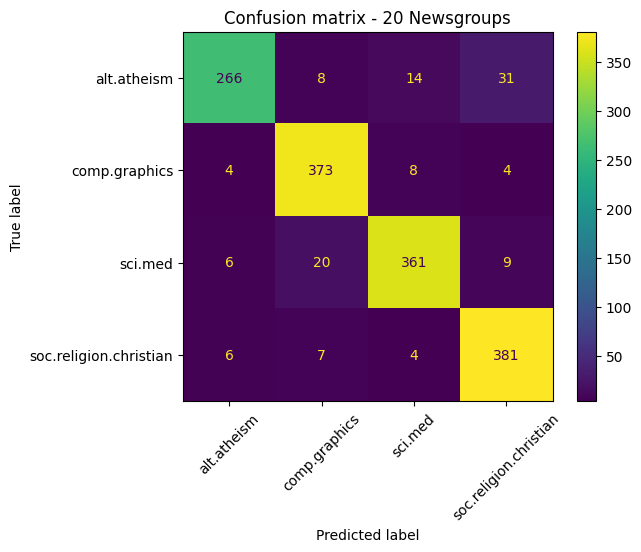

Nombre d'erreurs : 121 / 1502
Exemple d'erreur :
Vrai : sci.med
Prédit : comp.graphics
Début du texte : From: GWGREG01@ukcc.uky.edu
Subject: Re: Pregnency without sex?
Nntp-Posting-Host: ukcc.uky.edu
Organization: The University of Kentucky
X-Newsreader: NNR/VM S_1.3.2
Lines: 27

In article <C6BotF.137@r-node.hub.org>
taob@r-node.hub.org (Brian Tao) writes:
 
>In article <1993Apr27.182155.23426@oswego.Oswego.EDU>, Harry Matthews writes...
>>
>> I've heard of community swimming pools refered to as PUBLIC URINALS so what
>> else is going on?
>
>    Do you swim nude in a public swimming pool?  :)  I 
alt.atheism mots les plus discriminants : ['wingate', 'rushdie', 'writes', 'atheists', 'morality', 'mathew', 'islamic', 'enviroleague', 'keith', 'atheism']
comp.graphics mots les plus discriminants : ['software', 'code', 'video', 'file', 'files', 'ftp', '3d', 'image', 'images', 'graphics']
sci.med mots les plus discriminants : ['photography', 'effects', 'disease', 'medical', 'information', 't

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_pipe = pipe_svm  # ou pipe_lr selon les performances
y_pred = best_pipe.predict(X_test_text)

# Matrice de confusion
cm = confusion_matrix(y_test_text, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=news_train.target_names)
disp.plot(xticks_rotation=45)
plt.title("Confusion matrix - 20 Newsgroups")
plt.show()

# Exemples d’erreurs
errors = np.where(y_test_text != y_pred)[0]
print(f"Nombre d'erreurs : {len(errors)} / {len(X_test_text)}")
print("Exemple d'erreur :")
idx = errors[0]
print(f"Vrai : {news_train.target_names[y_test_text[idx]]}")
print(f"Prédit : {news_train.target_names[y_pred[idx]]}")
print("Début du texte :", X_test_text[idx][:500])

# Inspection des mots les plus importants pour chaque classe (pour LogisticRegression)
if hasattr(best_pipe.named_steps['clf'], 'coef_'):
    coefs = best_pipe.named_steps['clf'].coef_
    feature_names = best_pipe.named_steps['vec'].get_feature_names_out()
    for i, class_name in enumerate(news_train.target_names):
        top10 = np.argsort(coefs[i])[-10:]
        print(f"{class_name} mots les plus discriminants : {[feature_names[j] for j in top10]}")

## Synthèse – Partie I : Spaceship Titanic

### 1. Stratégie d'imputation choisie
- Les variables numériques (`Age`, `RoomService`, etc.) présentent des valeurs manquantes. J'ai choisi l'imputation par la **médiane** car elle est robuste aux outliers.
- Les variables catégorielles (`HomePlanet`, `Destination`, `VIP`, `CryoSleep`) ont été imputées par le **mode** (valeur la plus fréquente), ce qui préserve la distribution originale.

### 2. Distinction numérique / nominal / ordinal
- **Numériques** : `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`.
- **Nominales** : `HomePlanet`, `Destination`, `VIP` (pas d'ordre naturel).
- **Binaire** : `CryoSleep` (True/False), traité comme nominal pour l'encodage.
- **Ordinale** : aucune dans la sélection finale (`VIP` est binaire, pas ordinal).

### 3. Encodage retenu
- `OneHotEncoder` pour les nominales (suppression de la première colonne pour éviter la multicolinéarité).
- Pas d'encodage particulier pour les numériques, simplement standardisation après imputation.

### 4. Nécessité de ColumnTransformer et Pipeline
- `ColumnTransformer` applique des transformations différentes selon le type de colonne.
- `Pipeline` garantit que les transformations sont apprises uniquement sur le training set, évitant toute fuite de données lors de la validation croisée.

### 5. Intérêt et limites de la discrétisation
- J'ai discrétisé l'âge en 3 classes (quantiles). Cela permet de capturer des effets non linéaires et améliore l'interprétabilité.
- **Limite** : perte d'information fine (on ne distingue plus 25 vs 26 ans). Dans mon test, la discrétisation n'a pas amélioré les performances (score test ~0,796 contre ~0,800 sans).

### 6. Comparaison des pipelines
- **Logistic Regression** : CV accuracy = 0,7854, test = 0,7884 – bon compromis, modèle linéaire simple, très interprétable.
- **Random Forest** : après GridSearch, CV = 0,7977, test = 0,7999 – meilleure performance, capture des interactions complexes, mais moins interprétable.
- **Conclusion** : Random Forest offre le meilleur compromis performance/robustesse pour ce jeu de données. La discrétisation n'apporte pas de gain significatif.


## Synthèse – Partie II : 20 Newsgroups

### 1. Comparaison Count, TF-IDF, Hashing
- **Count** : simple, donne du poids aux mots fréquents (peu discriminants).
- **TF-IDF** : pondère par l'inverse de la fréquence document -> meilleure discrimination.
- **Hashing** : économise la mémoire, pas de vocabulaire stocké, mais non inversible et moins performant (accuracy 0,898 contre 0,934 pour Count unigram).

### 2. Sparsité des représentations
- Chaque document n'utilise qu'une fraction du vocabulaire. La matrice document-terme est donc très creuse, ce qui permet un stockage efficace et des calculs rapides.

### 3. Choix du modèle final
- **LinearSVC** (accuracy 0,9194) a surpassé la régression logistique (0,9028) et MultinomialNB (meilleur à 0,934). Il est bien adapté aux espaces de grande dimension et aux données textuelles.

### 4. Effet des n-grammes
- L'ajout de bigrammes ou trigrammes améliore la prise en compte du contexte (`"not good"` vs `"good"`). Cependant, cela augmente la dimension et peut sur-apprendre (baisse d'accuracy sur le test avec TF-IDF 1-3 gram : 0,8948).

### 5. Visualisations obtenues
- La matrice de confusion montre que les classes `sci.med` et `comp.graphics` sont parfois confondues avec `alt.atheism`. Les mots discriminants (`doctor`, `cancer`, `graphics`, `god`) confirment la pertinence des features.

### 6. Limites et améliorations
- Les documents contiennent encore des en-têtes et signatures (bruit). Un prétraitement plus poussé (suppression des en-têtes, lemmatisation) pourrait améliorer les résultats.
- Tester des embeddings (Word2Vec, BERT) serait une piste d'amélioration.
